In [ ]:
import sys
# Fix matplotlib/IPython compatibility issue
import matplotlib
if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = matplotlib.rcParams.get
ros_path = '/opt/ros/jazzy/lib/python3.12/site-packages'
if ros_path not in sys.path:
    sys.path.append(ros_path)

import os
notebook_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Import the robot localization library
from robot_localization_from_watchtower import (
    WatchtowerRobotLocalizer, 
    compute_localization_error
)

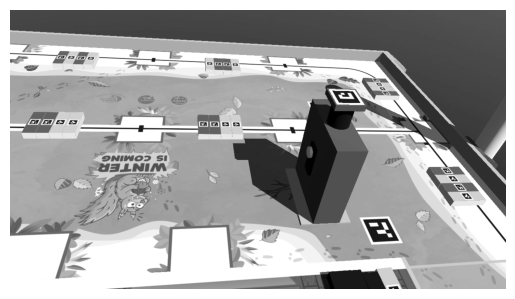

In [6]:
IMAGE_USED = 2 # 1 or 2
img_camera = cv2.imread('../../ressources/watchtower_view_with_robot'+str(IMAGE_USED)+'.png', 0) # Grayscale

# Display the image
plt.imshow(img_camera, cmap='gray')
plt.axis('off')
plt.show()

# Ground truth robot position (center at ground level)
if IMAGE_USED == 1:
    tag_pos_true = np.array([-1.24, -0.14, -0.002261+0.43])
elif IMAGE_USED == 2:
    tag_pos_true = np.array([-0.700161, 0.219973, -0.00257451+0.43])

# Ground truth orientation (quaternion x, y, z, w)
tag_quat_true = np.array([0, 0, 0, 1])

In [7]:
# Camera intrinsic parameters
camera_matrix = np.array([
    [914.0151876932167, 0.0, 640.0],
    [0.0, 914.0151876932167, 360.0],
    [0.0, 0.0, 1.0]
])
dist_coeffs = np.array([0, 0, 0, 0, 0], dtype=np.float32)

# Initialize the localizer
localizer = WatchtowerRobotLocalizer(
    camera_matrix=camera_matrix,
    dist_coeffs=dist_coeffs,
    marker_length=0.07,  # 7cm markers
    is_simu_with_webots=True
)

In [8]:
# Camera pose (ground truth from simulation)
camera_support_in_world_pos = np.array([-0.225, 1.12, 0.08])
camera_support_in_world_quat = np.array([0, 0, -0.707105, 0.707105])
camera_in_support_pos = np.array([0.0, 0.0, 0.91])
camera_in_support_quat = np.array([-0.031363, 0.34146, -0.0859194, 0.935435])

# Set camera pose in the localizer
localizer.set_camera_pose_from_transforms(
    support_pos=camera_support_in_world_pos,
    support_quat=camera_support_in_world_quat,
    camera_in_support_pos=camera_in_support_pos,
    camera_in_support_quat=camera_in_support_quat
)
print("Camera pose configured successfully")


Camera pose configured successfully


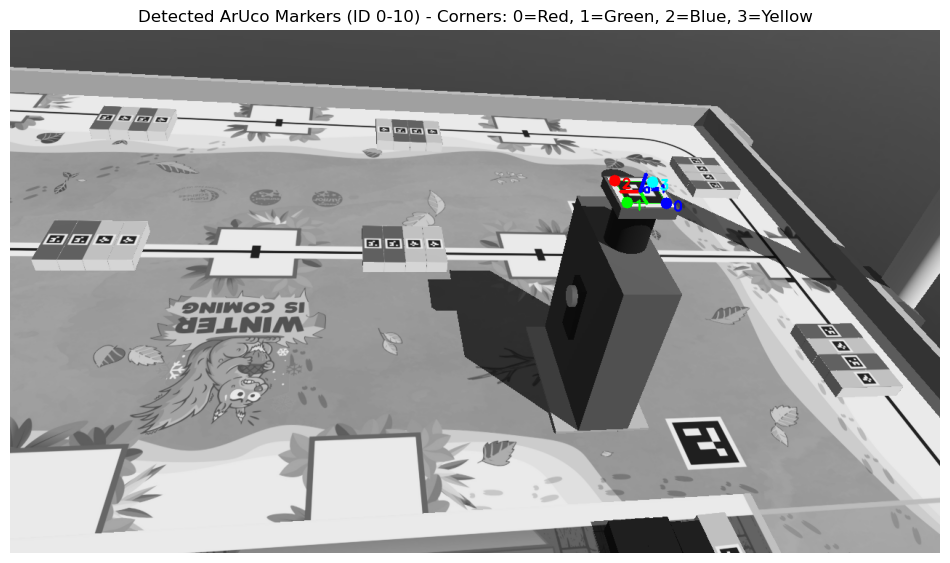

In [9]:
# Detect and visualize markers
img_with_markers = localizer.visualize_detections(
    img_camera,
    id_filter=(0, 10),
    draw_axes=True,
    draw_corner_numbers=True
)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img_with_markers, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Detected ArUco Markers (ID 0-10) - Corners: 0=Red, 1=Green, 2=Blue, 3=Yellow')
plt.show()

In [10]:
# Localize all robots in the image
robot_poses = localizer.localize_robots(img_camera, id_filter=(0, 10))

print(f"\nDetected {len(robot_poses)} markers:")
for marker_id, pose_data in robot_poses.items():
    print(f"\nMarker ID {marker_id}:")
    print(f"  Position (world frame): {pose_data['position']}")
    print(f"  Quaternion (world frame): {pose_data['quaternion']}")
    print(f"  Position (camera frame): {pose_data['tvec'].flatten()}")
    print(f"  Rotation vector: {pose_data['rvec'].flatten()}")


Detected 1 markers:

Marker ID 1:
  Position (world frame): [-0.71023375  0.19375242  0.43223798]
  Quaternion (world frame): (0.004029301581816804, 0.0028504152401886973, -0.004156884858520932, 0.9999791798682586)
  Position (camera frame): [ 0.28261031 -0.17010428  1.13827976]
  Rotation vector: [ 0.10883626  2.6991261  -1.26895472]


In [11]:
# Compute error for each detected marker
print("\n" + "="*60)
print("ERROR ANALYSIS")
print("="*60)

for marker_id, pose_data in robot_poses.items():
    position_error, angle_error_deg = compute_localization_error(
        estimated_pos=pose_data['position'],
        true_pos=tag_pos_true,
        estimated_quat=pose_data['quaternion'],
        true_quat=tag_quat_true
    )
    
    print(f"\n=== Marker ID {marker_id} ===")
    print(f"True position:      {tag_pos_true}")
    print(f"Estimated position: {pose_data['position']}")
    print(f"True orientation (quat):      {tag_quat_true}")
    print(f"Estimated orientation (quat): {pose_data['quaternion']}")
    print()
    print(f"Position error:     {position_error:.4f} m ({position_error*1000:.2f} mm)")
    print(f"Angle error:        {angle_error_deg:.2f}°")


ERROR ANALYSIS

=== Marker ID 1 ===
True position:      [-0.700161    0.219973    0.42742549]
Estimated position: [-0.71023375  0.19375242  0.43223798]
True orientation (quat):      [0 0 0 1]
Estimated orientation (quat): (0.004029301581816804, 0.0028504152401886973, -0.004156884858520932, 0.9999791798682586)

Position error:     0.0285 m (28.50 mm)
Angle error:        0.74°
